In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn openpyxl joblib


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install streamlit

  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   ----- ---------------------------------- 1.6/10.5 MB 8.0 MB/s eta 0:00:02
   ----------- ---------------------------- 3.1/10.5 MB 8.0 MB/s eta 0:00:01
   ----------------- ---------------------- 4.7/10.5 MB 7.9 MB/s eta 0:00:01
   ----------------------- ---------------- 6.3/10.5 MB 7.6 MB/s eta 0:00:01
   ----------------------------- ---------- 7.9/10.5 MB 7.6 MB/s eta 0:00:01
   ------------------------------------ --- 9.7/10.5 MB 7.9 MB/s eta 0:00:01
   ---------------------------------------- 10.5/10.5 MB 7.7 MB/s  0:00:01
   ---------------------------------------- 0.0/797.6 kB ? eta -:--:--
   ---------------------------------------- 797.6/797.6 kB 7.8 MB/s  0:00:00
   --------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastapi 0.109.2 requires starlette<0.37.0,>=0.36.3, but you have starlette 1.3.1 which is incompatible.

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
# ============================================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ============================================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Model evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Model saving
import joblib

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


In [38]:
# ============================================================
# STEP 2: LOAD DATASET
# ============================================================

# Path of the dataset
file_path = "data/california_housing_train.csv"

# Read CSV file
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [39]:
# ============================================================
# STEP 3: BASIC DATASET INFORMATION
# ============================================================

# Display first 5 rows
print("First 5 rows:")
display(df.head())

First 5 rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15,5612,1283,1015,472,1.49,66900
1,-114.47,34.40,19,7650,1901,1129,463,1.82,80100
2,-114.56,33.69,17,720,174,333,117,1.65,85700
3,-114.57,33.64,14,1501,337,515,226,3.19,73400
4,-114.57,33.57,20,1454,326,624,262,1.93,65500


In [40]:
# Display last 5 rows
print("Last 5 rows:")
display(df.tail())

Last 5 rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
16995,-124.26,40.58,52,2217,394,907,369,2.36,111400
16996,-124.27,40.69,36,2349,528,1194,465,2.52,79000
16997,-124.30,41.84,17,2677,531,1244,456,3.03,103600
16998,-124.30,41.80,19,2672,552,1298,478,1.98,85800
16999,-124.35,40.54,52,1820,300,806,270,3.01,94600


In [41]:
# Dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 17000
Number of columns: 9


In [42]:
# ============================================================
# STEP 4: COLUMN INFORMATION
# ============================================================

# Display column names
print("Column names:")
for column in df.columns:
    print("-", column)

Column names:
- longitude
- latitude
- housing_median_age
- total_rooms
- total_bedrooms
- population
- households
- median_income
- median_house_value


In [44]:
# ============================================================
# STEP 5: CHECK DATA TYPES
# ============================================================

print(df.dtypes)

longitude             float64
latitude              float64
housing_median_age      int64
total_rooms             int64
total_bedrooms          int64
population              int64
households              int64
median_income         float64
median_house_value      int64
dtype: object


In [45]:
# ============================================================
# STEP 6: DATASET INFORMATION
# ============================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  int64  
 3   total_rooms         17000 non-null  int64  
 4   total_bedrooms      17000 non-null  int64  
 5   population          17000 non-null  int64  
 6   households          17000 non-null  int64  
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 1.2 MB


In [46]:
# ============================================================
# STEP 7: STATISTICAL SUMMARY
# ============================================================

df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.00,17000.00,17000.00,17000.00,17000.00,17000.00,17000.00,17000.00,17000.00
mean,-119.56,35.63,28.59,2643.66,539.41,1429.57,501.22,3.88,207300.91
std,2.01,2.14,12.59,2179.95,421.50,1147.85,384.52,1.91,115983.76
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,14999.00
25%,-121.79,33.93,18.00,1462.00,297.00,790.00,282.00,2.57,119400.00
50%,-118.49,34.25,29.00,2127.00,434.00,1167.00,409.00,3.54,180400.00
75%,-118.00,37.72,37.00,3151.25,648.25,1721.00,605.25,4.77,265000.00
max,-114.31,41.95,52.00,37937.00,6445.00,35682.00,6082.00,15.00,500001.00


In [47]:
# ============================================================
# STEP 8: MISSING VALUE ANALYSIS
# ============================================================

missing_values = df.isnull().sum()

print("Missing values in each column:")
display(missing_values)

Missing values in each column:


longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64

In [48]:
# Calculate missing-value percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

display(missing_summary)

,Missing Values,Missing Percentage
longitude,0,0.00
latitude,0,0.00
housing_median_age,0,0.00
total_rooms,0,0.00
total_bedrooms,0,0.00
population,0,0.00
households,0,0.00
median_income,0,0.00
median_house_value,0,0.00


In [49]:
# ============================================================
# STEP 9: DUPLICATE ANALYSIS
# ============================================================

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [50]:
target = "median_house_value"

In [51]:
# ============================================================
# STEP 10: TARGET VARIABLE ANALYSIS
# ============================================================

target = "median_house_value"

print("Target variable:", target)

print("\nTarget statistics:")
display(df[target].describe())

Target variable: median_house_value

Target statistics:


count    17000.00
mean    207300.91
std     115983.76
min      14999.00
25%     119400.00
50%     180400.00
75%     265000.00
max     500001.00
Name: median_house_value, dtype: float64

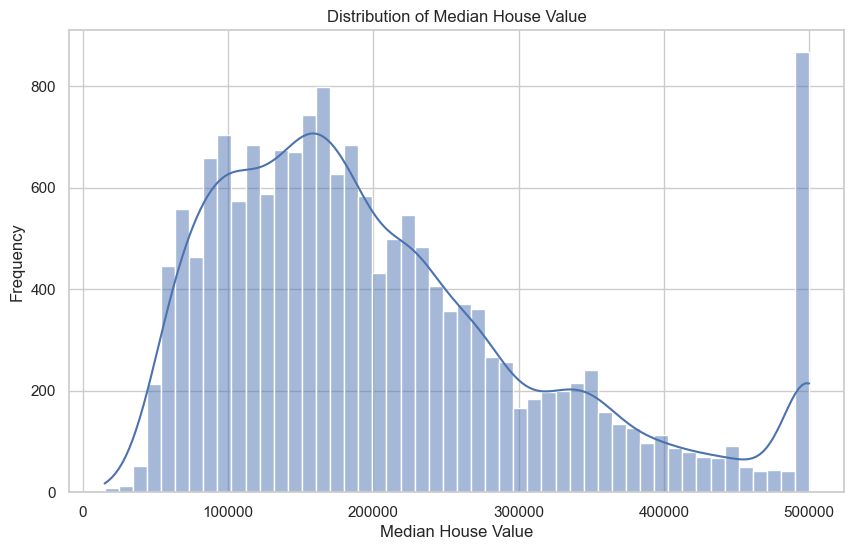

In [52]:
# Distribution of house prices

plt.figure(figsize=(10, 6))

sns.histplot(
    df[target],
    bins=50,
    kde=True
)

plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")

plt.show()

In [53]:
# ============================================================
# STEP 11: CORRELATION ANALYSIS
# ============================================================

correlation_matrix = df.corr(numeric_only=True)

display(correlation_matrix)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.00,-0.93,-0.11,0.05,0.07,0.10,0.06,-0.02,-0.04
latitude,-0.93,1.00,0.02,-0.04,-0.07,-0.11,-0.07,-0.08,-0.14
housing_median_age,-0.11,0.02,1.00,-0.36,-0.32,-0.30,-0.30,-0.12,0.11
total_rooms,0.05,-0.04,-0.36,1.00,0.93,0.86,0.92,0.20,0.13
total_bedrooms,0.07,-0.07,-0.32,0.93,1.00,0.88,0.98,-0.01,0.05
population,0.10,-0.11,-0.30,0.86,0.88,1.00,0.91,-0.00,-0.03
households,0.06,-0.07,-0.30,0.92,0.98,0.91,1.00,0.01,0.06
median_income,-0.02,-0.08,-0.12,0.20,-0.01,-0.00,0.01,1.00,0.69
median_house_value,-0.04,-0.14,0.11,0.13,0.05,-0.03,0.06,0.69,1.00


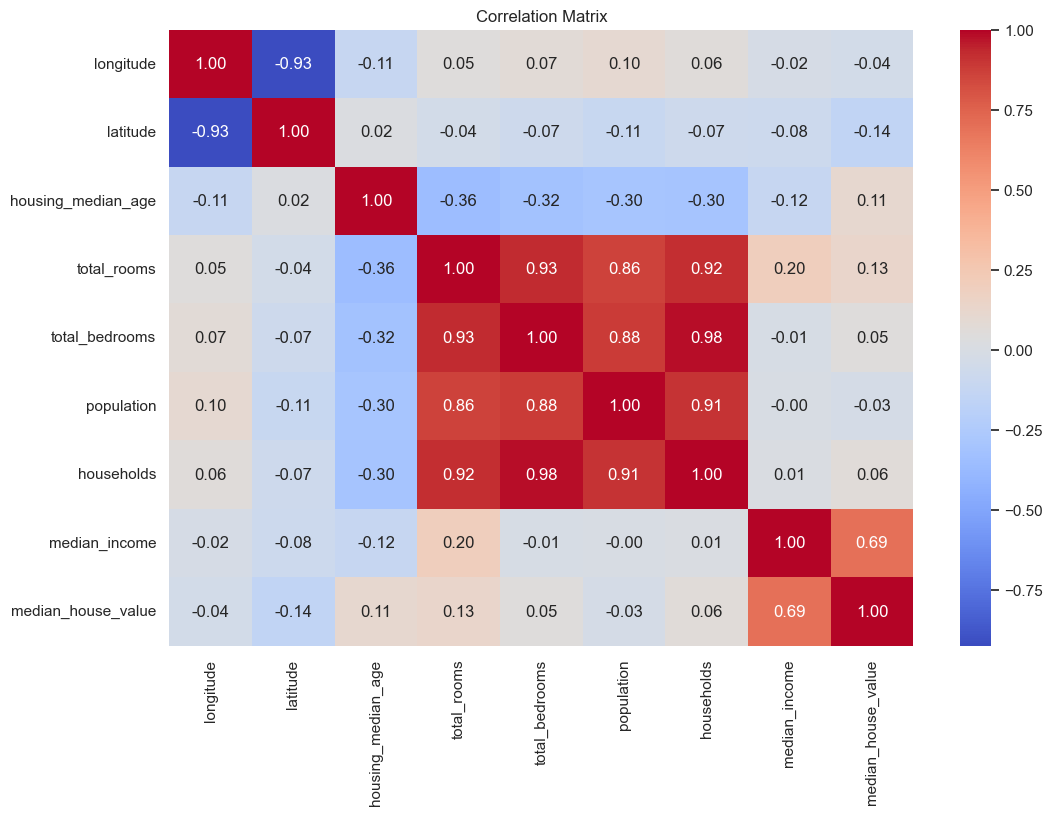

In [54]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [55]:
df[["median_income", "median_house_value"]].corr()

,median_income,median_house_value
median_income,1.00,0.69
median_house_value,0.69,1.00


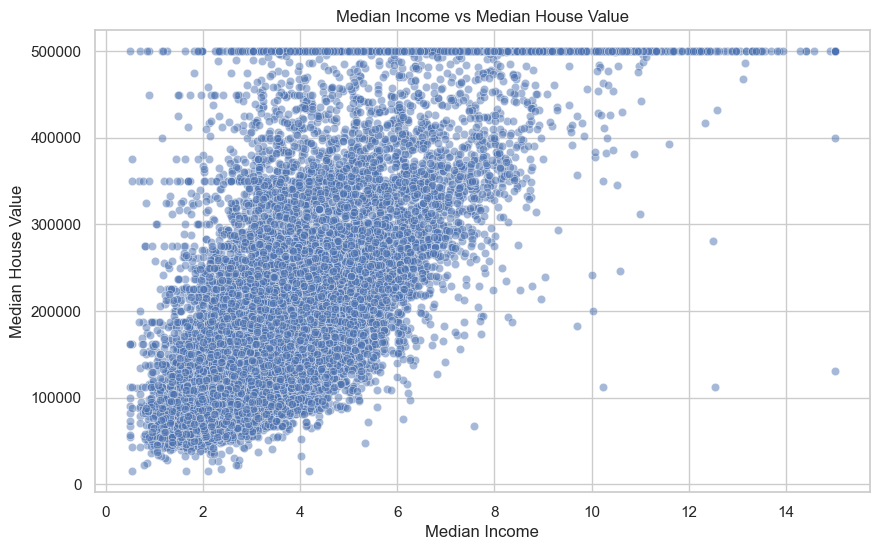

In [56]:
# ============================================================
# MEDIAN INCOME VS HOUSE VALUE
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="median_income",
    y="median_house_value",
    alpha=0.5
)

plt.title("Median Income vs Median House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")

plt.show()

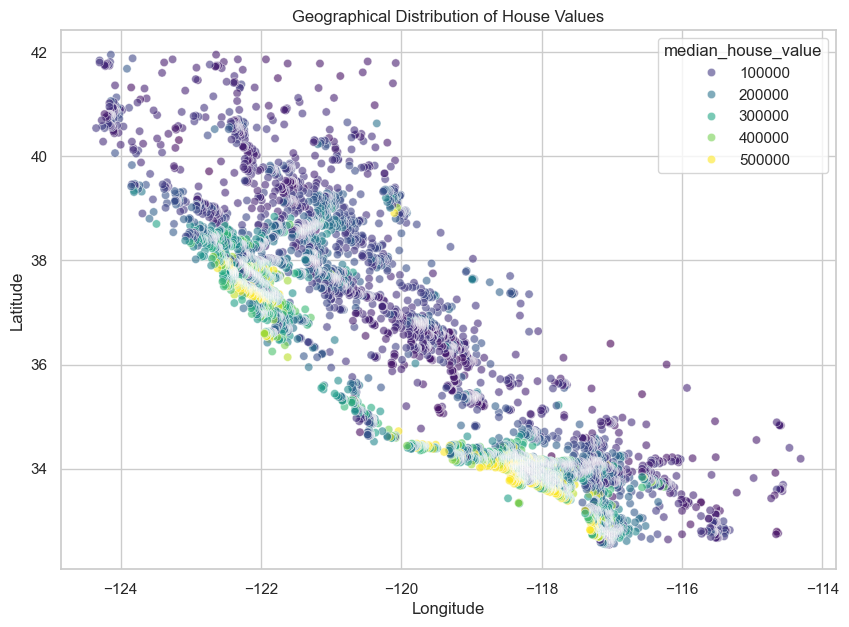

In [57]:
# ============================================================
# GEOGRAPHICAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="longitude",
    y="latitude",
    hue="median_house_value",
    palette="viridis",
    alpha=0.6
)

plt.title("Geographical Distribution of House Values")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

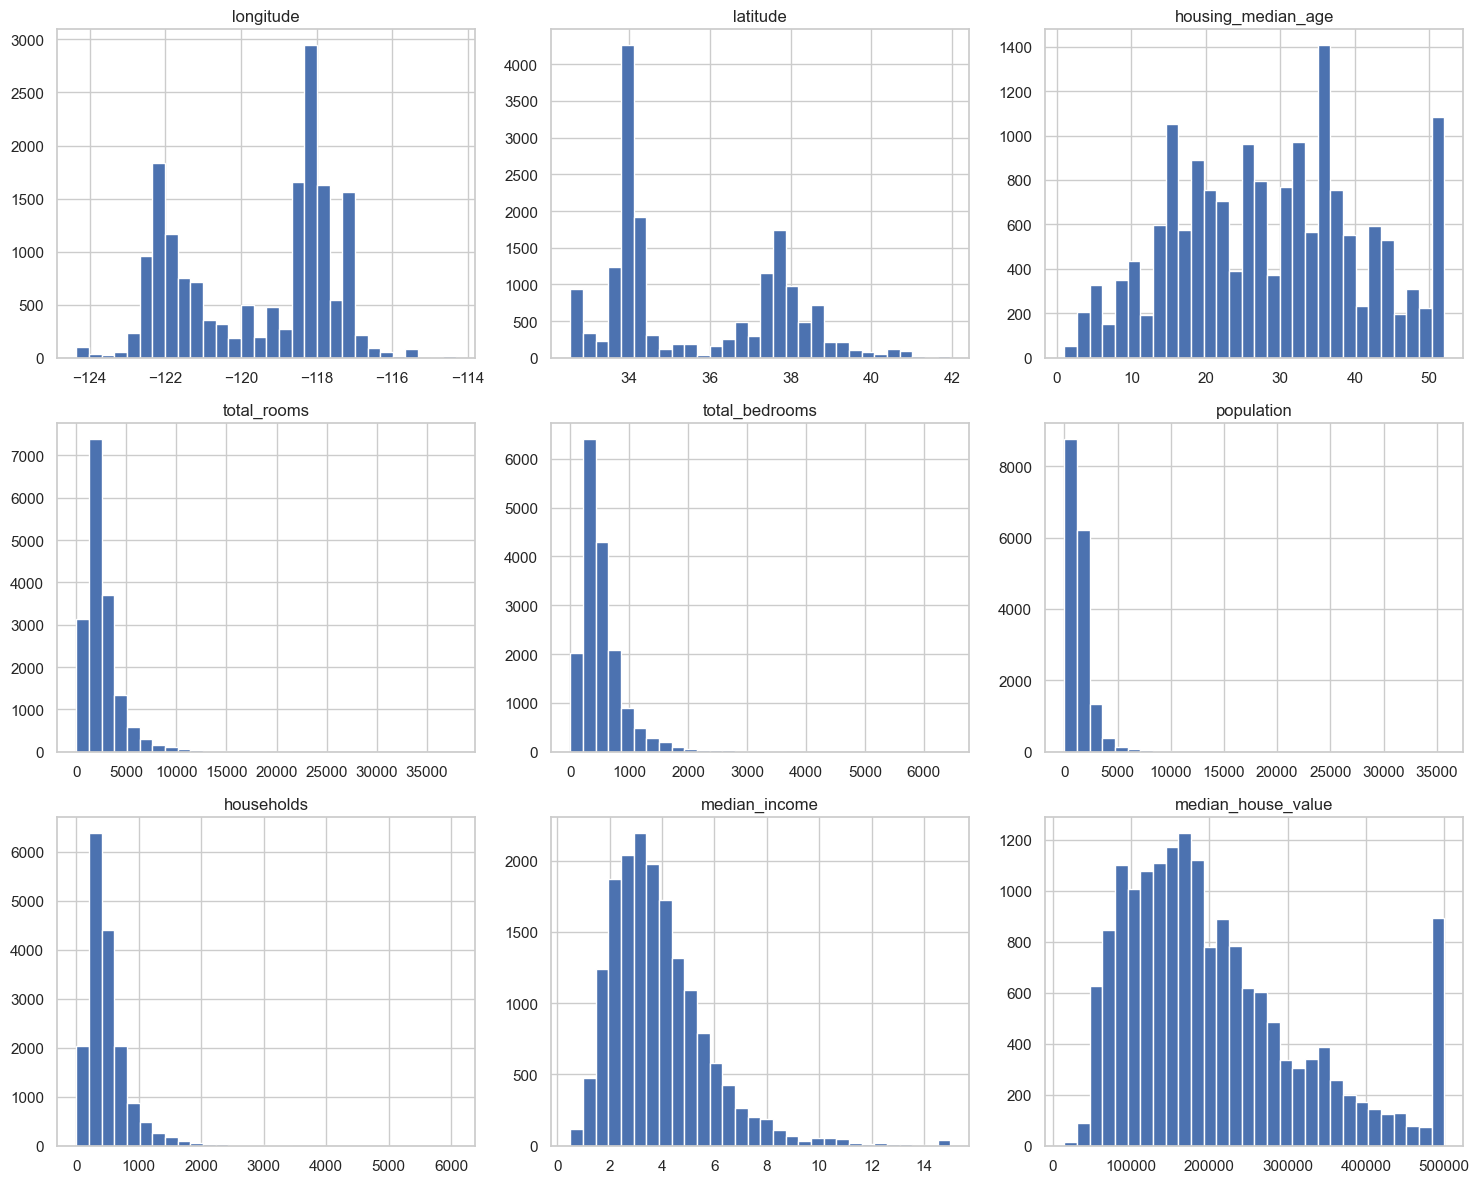

In [58]:
# ============================================================
# FEATURE DISTRIBUTIONS
# ============================================================

df.hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

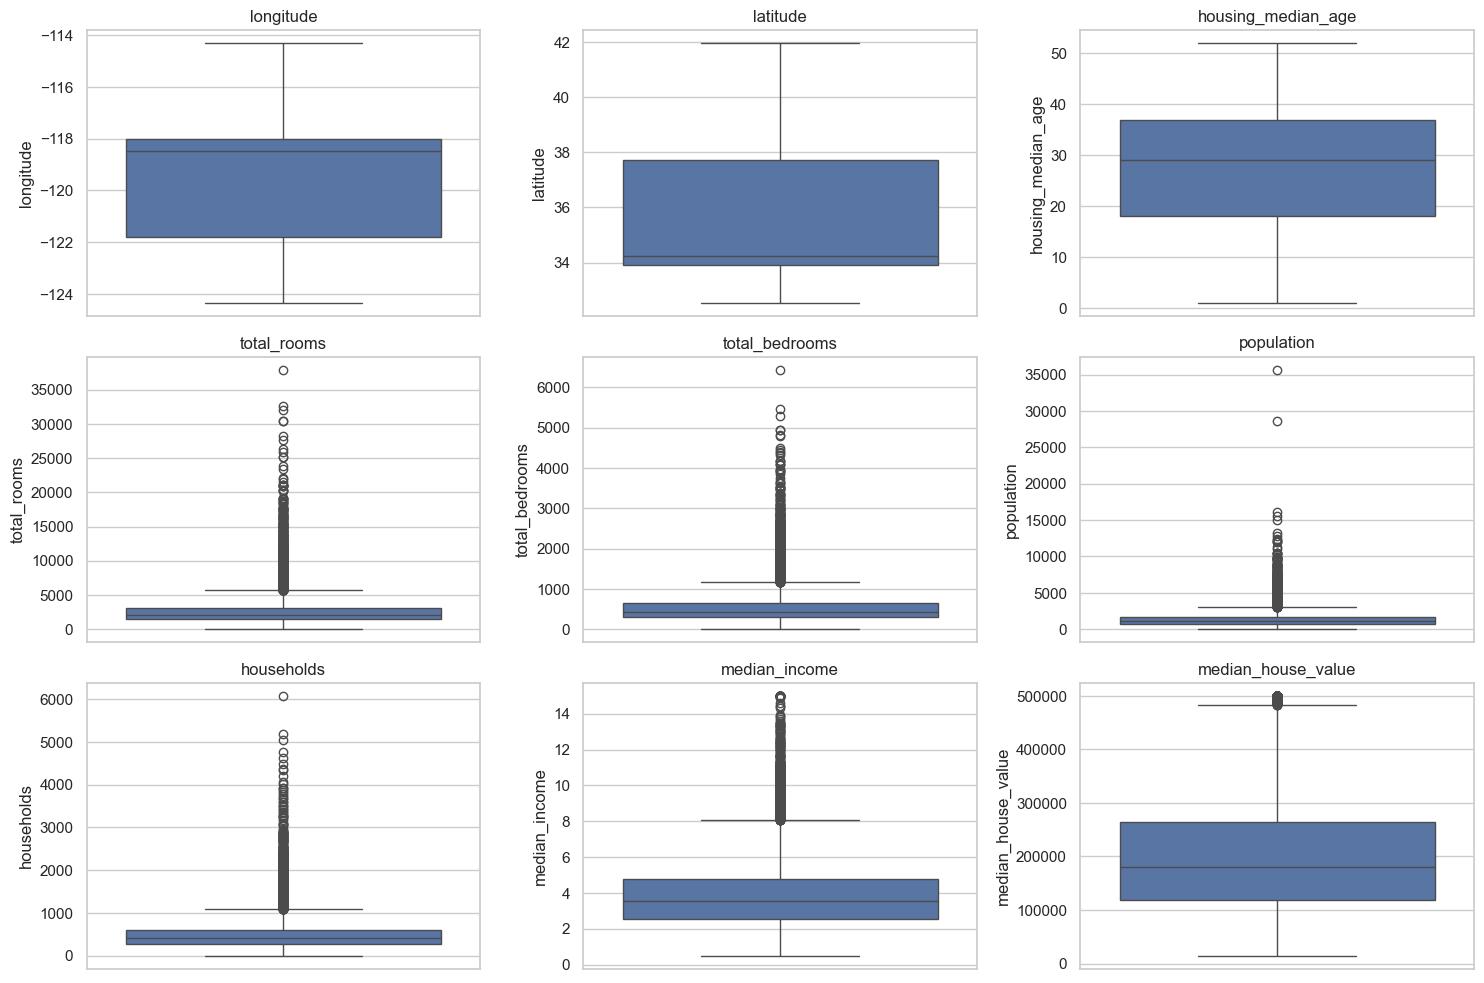

In [59]:
# ============================================================
# OUTLIER ANALYSIS
# ============================================================

plt.figure(figsize=(15, 10))

for i, column in enumerate(df.columns, 1):

    plt.subplot(3, 3, i)

    sns.boxplot(
        y=df[column]
    )

    plt.title(column)

plt.tight_layout()
plt.show()

In [61]:
target = "median_house_value"

In [62]:
# ============================================================
# STEP 16: SEPARATE FEATURES (X) AND TARGET (y)
# ============================================================

# Target variable
target = "median_house_value"

# X = input features
X = df.drop(columns=[target])

# y = value that we want to predict
y = df[target]

print("Features (X):")
display(X.head())

print("\nTarget (y):")
display(y.head())

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Features (X):


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-114.31,34.19,15,5612,1283,1015,472,1.49
1,-114.47,34.40,19,7650,1901,1129,463,1.82
2,-114.56,33.69,17,720,174,333,117,1.65
3,-114.57,33.64,14,1501,337,515,226,3.19
4,-114.57,33.57,20,1454,326,624,262,1.93



Target (y):


0    66900
1    80100
2    85700
3    73400
4    65500
Name: median_house_value, dtype: int64


Shape of X: (17000, 8)
Shape of y: (17000,)


In [63]:
# ============================================================
# STEP 17: FINAL FEATURE CHECK
# ============================================================

print("Feature names:")
for feature in X.columns:
    print("-", feature)

Feature names:
- longitude
- latitude
- housing_median_age
- total_rooms
- total_bedrooms
- population
- households
- median_income


In [64]:
# ============================================================
# STEP 18: CHECK MISSING VALUES IN X AND y
# ============================================================

print("Missing values in X:")
print(X.isnull().sum())

print("\nMissing values in y:")
print(y.isnull().sum())

Missing values in X:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
dtype: int64

Missing values in y:
0


In [65]:
# ============================================================
# STEP 19: TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training data:
X_train: (13600, 8)
y_train: (13600,)

Testing data:
X_test: (3400, 8)
y_test: (3400,)


In [66]:
# ============================================================
# STEP 21: CREATE RANDOM FOREST REGRESSOR
# ============================================================

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Random Forest Regressor created successfully.")

Random Forest Regressor created successfully.


In [67]:
# ============================================================
# STEP 22: TRAIN RANDOM FOREST MODEL
# ============================================================

print("Training Random Forest...")

rf_model.fit(
    X_train,
    y_train
)

print("Model training completed successfully!")

Training Random Forest...
Model training completed successfully!


In [68]:
# ============================================================
# STEP 23: MAKE PREDICTIONS
# ============================================================

y_pred = rf_model.predict(X_test)

print("Predictions generated successfully.")

print("\nFirst 10 predictions:")
print(y_pred[:10])

Predictions generated successfully.

First 10 predictions:
[148691.   479174.54  80242.   142684.    97585.   267033.02 172781.
 164382.   371683.04 239383.03]


In [69]:
# ============================================================
# STEP 24: ACTUAL VS PREDICTED VALUES
# ============================================================

comparison = pd.DataFrame({
    "Actual Value": y_test.values,
    "Predicted Value": y_pred
})

comparison["Difference"] = (
    comparison["Actual Value"] -
    comparison["Predicted Value"]
)

display(comparison.head(10))

,Actual Value,Predicted Value,Difference
0,142700,148691.00,-5991.00
1,500001,479174.54,20826.46
2,61800,80242.00,-18442.00
3,162800,142684.00,20116.00
4,90600,97585.00,-6985.00
5,232100,267033.02,-34933.02
6,147800,172781.00,-24981.00
7,133300,164382.00,-31082.00
8,438500,371683.04,66816.96
9,187700,239383.03,-51683.03


In [70]:
# ============================================================
# STEP 25: MEAN ABSOLUTE ERROR
# ============================================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

print(f"Mean Absolute Error: ${mae:,.2f}")

Mean Absolute Error: $32,359.79


In [71]:
# ============================================================
# STEP 26: MEAN SQUARED ERROR
# ============================================================

mse = mean_squared_error(
    y_test,
    y_pred
)

print(f"Mean Squared Error: {mse:,.2f}")

Mean Squared Error: 2,441,797,346.98


In [72]:
# ============================================================
# STEP 27: ROOT MEAN SQUARED ERROR
# ============================================================

rmse = np.sqrt(mse)

print(f"Root Mean Squared Error: ${rmse:,.2f}")

Root Mean Squared Error: $49,414.55


In [73]:
# ============================================================
# STEP 28: R-SQUARED SCORE
# ============================================================

r2 = r2_score(
    y_test,
    y_pred
)

print(f"R² Score: {r2:.4f}")

R² Score: 0.8228


In [74]:
# ============================================================
# STEP 29: MODEL EVALUATION SUMMARY
# ============================================================

evaluation = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R² Score"
    ],
    "Value": [
        mae,
        mse,
        rmse,
        r2
    ]
})

display(evaluation)

,Metric,Value
0,MAE,32359.79
1,MSE,2441797346.98
2,RMSE,49414.55
3,R² Score,0.82


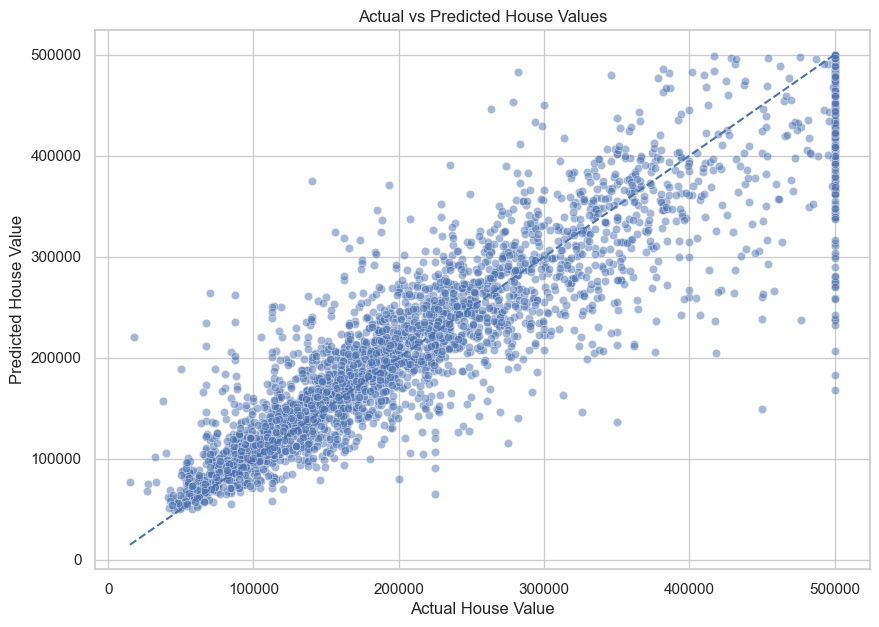

In [75]:
# ============================================================
# STEP 30: ACTUAL VS PREDICTED VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=y_test,
    y=y_pred,
    alpha=0.5
)

# Perfect prediction line
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")

plt.show()

In [76]:
# ============================================================
# STEP 31: FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
7,median_income,0.52
0,longitude,0.17
1,latitude,0.16
2,housing_median_age,0.06
5,population,0.03
3,total_rooms,0.02
4,total_bedrooms,0.02
6,households,0.02


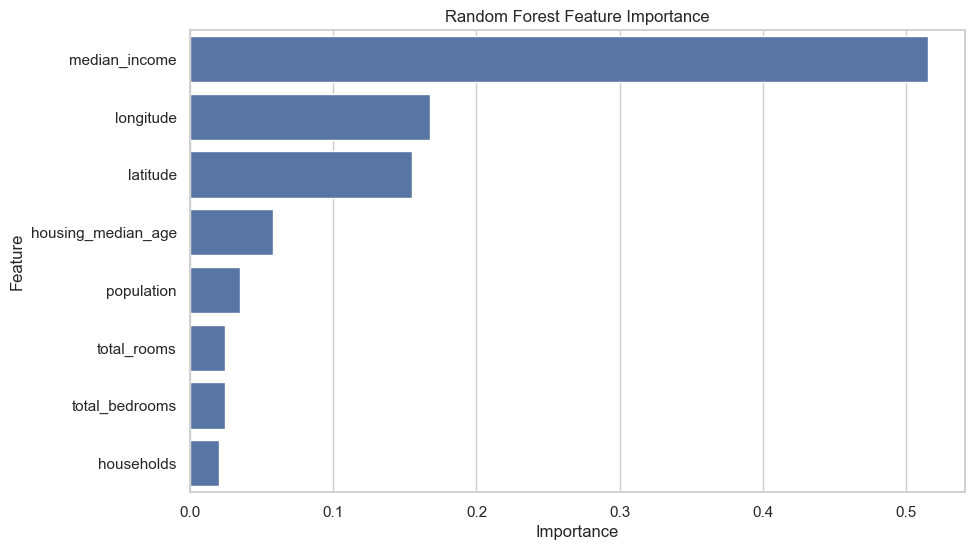

In [78]:
# ============================================================
# FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [79]:
# ============================================================
# STEP 32: SAVE TRAINED MODEL
# ============================================================

model_path = "random_forest_house_price_model.pkl"

joblib.dump(
    rf_model,
    model_path
)

print(f"Model saved successfully: {model_path}")

Model saved successfully: random_forest_house_price_model.pkl


In [80]:
# ============================================================
# STEP 33: LOAD SAVED MODEL
# ============================================================

loaded_model = joblib.load(
    "random_forest_house_price_model.pkl"
)

print("Saved model loaded successfully.")

Saved model loaded successfully.


In [81]:
# ============================================================
# STEP 34: TEST ONE PREDICTION
# ============================================================

sample_house = X_test.iloc[[0]]

actual_value = y_test.iloc[0]

predicted_value = loaded_model.predict(
    sample_house
)[0]

print(f"Actual House Value: ${actual_value:,.2f}")
print(f"Predicted House Value: ${predicted_value:,.2f}")

Actual House Value: $142,700.00
Predicted House Value: $148,691.00


In [82]:
X_test.iloc[[0]]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
10941,-120.87,37.77,9,4838,920,2460,923,3.60


In [83]:
X_test.iloc[0]

longitude            -120.87
latitude               37.77
housing_median_age      9.00
total_rooms          4838.00
total_bedrooms        920.00
population           2460.00
households            923.00
median_income           3.60
Name: 10941, dtype: float64

In [84]:
RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [85]:
# ============================================================
# STEP 36: IMPORT HYPERPARAMETER TUNING TOOLS
# ============================================================

from sklearn.model_selection import RandomizedSearchCV

print("Hyperparameter tuning tools imported successfully.")

Hyperparameter tuning tools imported successfully.


In [86]:
# ============================================================
# STEP 37: DEFINE RANDOM FOREST PARAMETERS
# ============================================================

param_grid = {
    "n_estimators": [100, 200, 300, 500],

    "max_depth": [
        None,
        10,
        20,
        30
    ],

    "min_samples_split": [
        2,
        5,
        10
    ],

    "min_samples_leaf": [
        1,
        2,
        4
    ],

    "max_features": [
        1.0,
        "sqrt",
        "log2"
    ]
}

print("Parameter search space created.")

Parameter search space created.


In [87]:
# ============================================================
# STEP 38: CREATE RANDOMIZED SEARCH
# ============================================================

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),

    param_distributions=param_grid,

    n_iter=20,

    scoring="neg_root_mean_squared_error",

    cv=3,

    verbose=2,

    random_state=42,

    n_jobs=-1
)

print("RandomizedSearchCV created successfully.")

RandomizedSearchCV created successfully.


In [89]:
# ============================================================
# STEP 39: RUN HYPERPARAMETER SEARCH
# ============================================================

print("Starting hyperparameter tuning...")

random_search.fit(
    X_train,
    y_train
)

print("Hyperparameter tuning completed!")

Starting hyperparameter tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Hyperparameter tuning completed!


In [90]:
# ============================================================
# STEP 40: DISPLAY BEST PARAMETERS
# ============================================================

print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 1.0, 'max_depth': None}


In [91]:
# ============================================================
# STEP 41: BEST CROSS-VALIDATION SCORE
# ============================================================

best_cv_rmse = -random_search.best_score_

print(
    f"Best Cross-Validation RMSE: ${best_cv_rmse:,.2f}"
)

Best Cross-Validation RMSE: $50,828.20


In [92]:
-random_search.best_score_

np.float64(50828.20417584535)

In [93]:
# ============================================================
# STEP 42: EXTRACT BEST MODEL
# ============================================================

best_rf_model = random_search.best_estimator_

print("Best Random Forest model selected.")

Best Random Forest model selected.


In [94]:
# ============================================================
# STEP 43: PREDICTIONS FROM TUNED MODEL
# ============================================================

y_pred_tuned = best_rf_model.predict(
    X_test
)

print("Tuned model predictions generated.")

Tuned model predictions generated.


In [95]:
# ============================================================
# STEP 44: EVALUATE TUNED MODEL
# ============================================================

tuned_mae = mean_absolute_error(
    y_test,
    y_pred_tuned
)

tuned_mse = mean_squared_error(
    y_test,
    y_pred_tuned
)

tuned_rmse = np.sqrt(
    tuned_mse
)

tuned_r2 = r2_score(
    y_test,
    y_pred_tuned
)

print(f"MAE  : ${tuned_mae:,.2f}")
print(f"MSE  : {tuned_mse:,.2f}")
print(f"RMSE : ${tuned_rmse:,.2f}")
print(f"R²   : {tuned_r2:.4f}")

MAE  : $32,430.22
MSE  : 2,461,796,584.18
RMSE : $49,616.50
R²   : 0.8213


In [96]:
# ============================================================
# STEP 45: BASELINE VS TUNED MODEL
# ============================================================

model_comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Tuned Random Forest"
    ],

    "MAE": [
        mae,
        tuned_mae
    ],

    "RMSE": [
        rmse,
        tuned_rmse
    ],

    "R²": [
        r2,
        tuned_r2
    ]
})

display(model_comparison)

,Model,MAE,RMSE,R²
0,Baseline Random Forest,32359.79,49414.55,0.82
1,Tuned Random Forest,32430.22,49616.50,0.82


In [97]:
# ============================================================
# STEP 46: CALCULATE MODEL IMPROVEMENT
# ============================================================

rmse_improvement = (
    (rmse - tuned_rmse) / rmse
) * 100

r2_improvement = (
    (tuned_r2 - r2) / r2
) * 100

print(
    f"RMSE improvement: {rmse_improvement:.2f}%"
)

print(
    f"R² improvement: {r2_improvement:.2f}%"
)

RMSE improvement: -0.41%
R² improvement: -0.18%


In [98]:
# ============================================================
# STEP 47: TUNED MODEL FEATURE IMPORTANCE
# ============================================================

tuned_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf_model.feature_importances_
})

tuned_feature_importance = (
    tuned_feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

display(tuned_feature_importance)

,Feature,Importance
7,median_income,0.54
0,longitude,0.17
1,latitude,0.16
2,housing_median_age,0.05
5,population,0.03
4,total_bedrooms,0.02
3,total_rooms,0.02
6,households,0.01


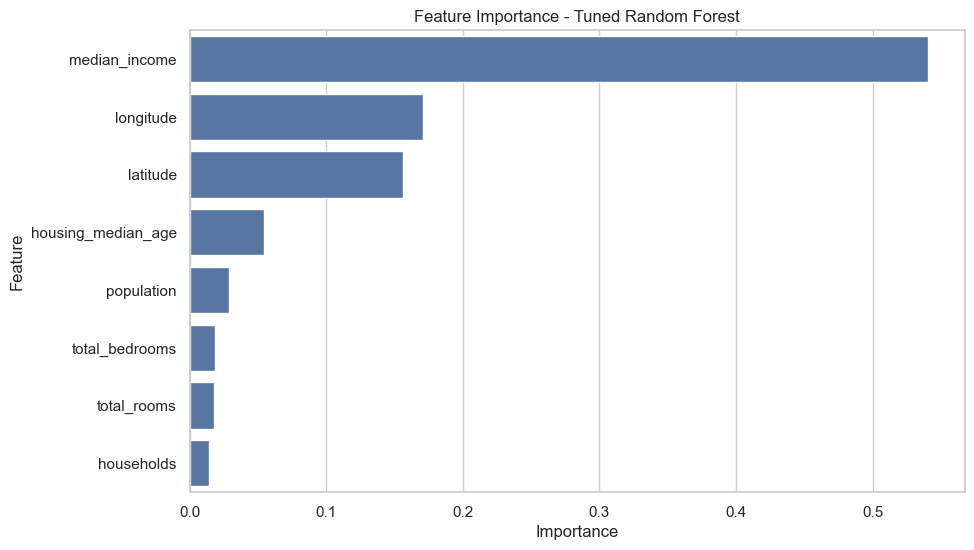

In [99]:
# ============================================================
# STEP 48: TUNED FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=tuned_feature_importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Feature Importance - Tuned Random Forest"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [100]:
# ============================================================
# STEP 49: PREDICTION ERROR ANALYSIS
# ============================================================

error_analysis = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_tuned
})

error_analysis["Error"] = (
    error_analysis["Actual"] -
    error_analysis["Predicted"]
)

error_analysis["Absolute Error"] = (
    error_analysis["Error"].abs()
)

display(
    error_analysis.head(10)
)

,Actual,Predicted,Error,Absolute Error
0,142700,145748.42,-3048.42,3048.42
1,500001,472868.78,27132.22,27132.22
2,61800,87631.94,-25831.94,25831.94
3,162800,150978.34,11821.66,11821.66
4,90600,100178.90,-9578.90,9578.90
5,232100,273373.72,-41273.72,41273.72
6,147800,172334.40,-24534.40,24534.40
7,133300,187110.82,-53810.82,53810.82
8,438500,374943.17,63556.83,63556.83
9,187700,230598.40,-42898.40,42898.40


In [101]:
# ============================================================
# STEP 50: LARGEST PREDICTION ERRORS
# ============================================================

largest_errors = (
    error_analysis
    .sort_values(
        by="Absolute Error",
        ascending=False
    )
    .head(20)
)

display(largest_errors)

,Actual,Predicted,Error,Absolute Error
449,500001,138040.39,361960.61,361960.61
1581,500000,167889.92,332110.08,332110.08
848,500001,185957.84,314043.16,314043.16
340,450000,155331.57,294668.43,294668.43
152,500001,210308.34,289692.66,289692.66
2710,500001,232164.04,267836.96,267836.96
388,500001,232215.89,267785.11,267785.11
1421,500001,244117.43,255883.57,255883.57
2502,500001,247184.88,252816.12,252816.12
1883,500001,255155.39,244845.61,244845.61


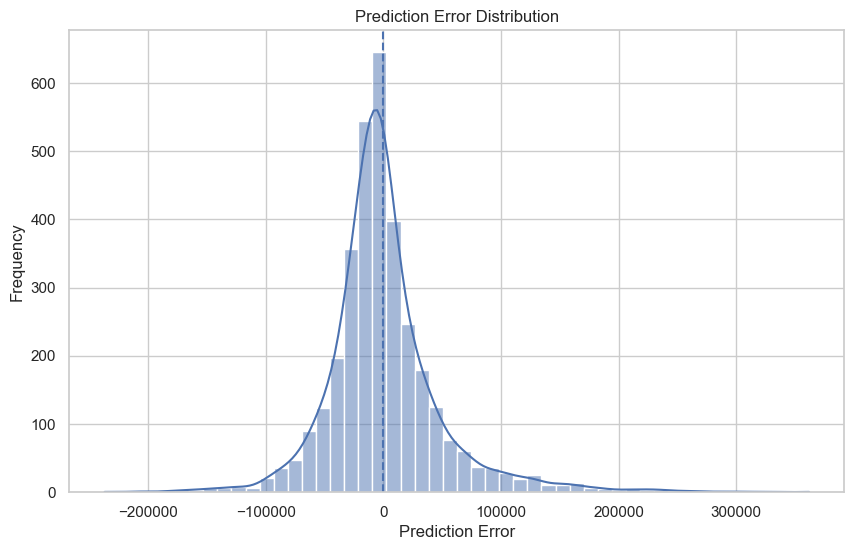

In [102]:
# ============================================================
# STEP 51: ERROR DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    error_analysis["Error"],
    bins=50,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Prediction Error Distribution")

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

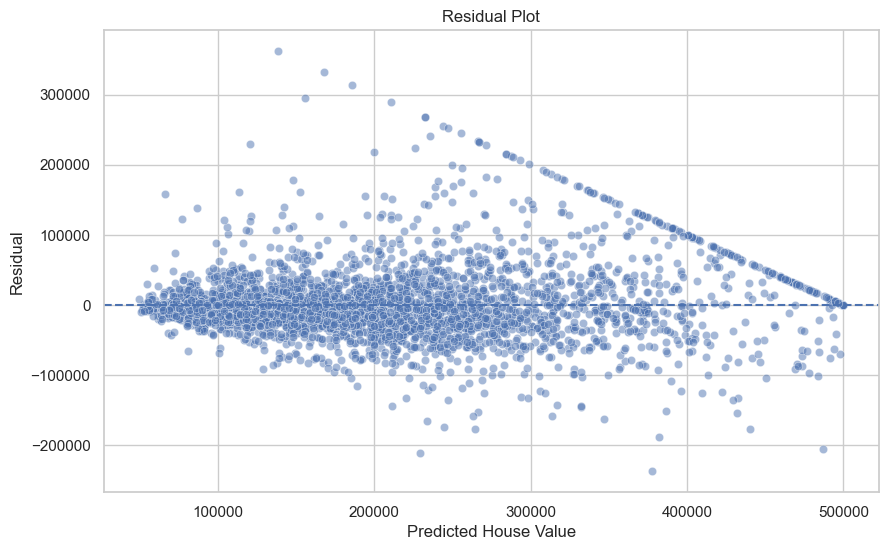

In [103]:
# ============================================================
# STEP 52: RESIDUAL ANALYSIS
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_pred_tuned,
    y=error_analysis["Error"],
    alpha=0.5
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Residual Plot")

plt.xlabel("Predicted House Value")

plt.ylabel("Residual")

plt.show()

In [104]:
# ============================================================
# STEP 53: SAVE FINAL TUNED MODEL
# ============================================================

final_model_path = "final_random_forest_house_price_model.pkl"

joblib.dump(
    best_rf_model,
    final_model_path
)

print(
    f"Final model saved successfully: "
    f"{final_model_path}"
)

Final model saved successfully: final_random_forest_house_price_model.pkl


In [105]:
# ============================================================
# STEP 54: CREATE REUSABLE PREDICTION FUNCTION
# ============================================================

def predict_house_price(
    longitude,
    latitude,
    housing_median_age,
    total_rooms,
    total_bedrooms,
    population,
    households,
    median_income
):
    """
    Predict the median house value using
    the trained Random Forest model.
    """

    # Create a DataFrame containing
    # exactly the same features used during training.
    input_data = pd.DataFrame({
        "longitude": [longitude],
        "latitude": [latitude],
        "housing_median_age": [housing_median_age],
        "total_rooms": [total_rooms],
        "total_bedrooms": [total_bedrooms],
        "population": [population],
        "households": [households],
        "median_income": [median_income]
    })

    # Generate prediction
    prediction = best_rf_model.predict(
        input_data
    )[0]

    return prediction

In [106]:
# ============================================================
# STEP 55: TEST PREDICTION FUNCTION
# ============================================================

prediction = predict_house_price(
    longitude=-122.23,
    latitude=37.88,
    housing_median_age=41,
    total_rooms=880,
    total_bedrooms=129,
    population=322,
    households=126,
    median_income=8.33
)

print(
    f"Predicted Median House Value: "
    f"${prediction:,.2f}"
)

Predicted Median House Value: $423,631.55


In [108]:
# ============================================================
# STEP 56: VERIFY FEATURE ORDER
# ============================================================

print("Features expected by the model:")

for feature in X_train.columns:
    print(feature)

Features expected by the model:
longitude
latitude
housing_median_age
total_rooms
total_bedrooms
population
households
median_income


In [109]:
# ============================================================
# STEP 57: SAVE MODEL METADATA
# ============================================================

model_metadata = {
    "target": target,
    "features": list(X_train.columns),
    "model_type": "RandomForestRegressor",
    "n_features": X_train.shape[1]
}

joblib.dump(
    model_metadata,
    "model_metadata.pkl"
)

print("Model metadata saved successfully.")

Model metadata saved successfully.
